In [192]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


In [195]:
node_labels = {}
G= nx.DiGraph()
G.add_node((1,1))
node_labels[(1,1)] = 100
G.add_node((2,1))
node_labels[(2,1)] = 80
G.add_node((2,2))
node_labels[(2,2)] = 120
G.add_node((3,1))
node_labels[(3,1)] = 64
G.add_node((3,2))
node_labels[(3,2)] = 96
G.add_node((3,3))
node_labels[(3,3)] = 144
G.add_edge((1,1), (2,1))
G.add_edge((1,1), (2,2))
G.add_edge((2,2), (3,3))
G.add_edge((2,2), (3,2))
G.add_edge((2,1), (3,1))
G.add_edge((2,1), (3,2))

In [196]:
G.nodes()

NodeView(((1, 1), (2, 1), (2, 2), (3, 1), (3, 2), (3, 3)))

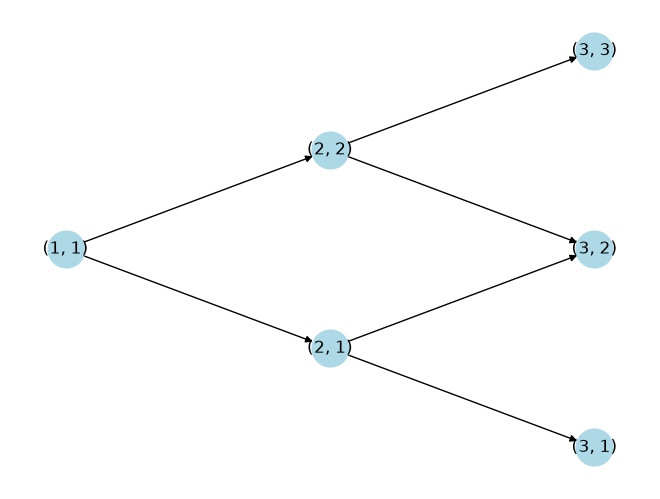

In [162]:
pos = {node: (node[0], node[1] - node[0] / 2) for node in G.nodes()}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=700,
    arrows=True
)


{(1, 1): Text(1, 0.5, '100'),
 (2, 1): Text(2, 0.0, '80'),
 (2, 2): Text(2, 1.0, '120'),
 (3, 1): Text(3, -0.5, '64'),
 (3, 2): Text(3, 0.5, '96'),
 (3, 3): Text(3, 1.5, '144')}

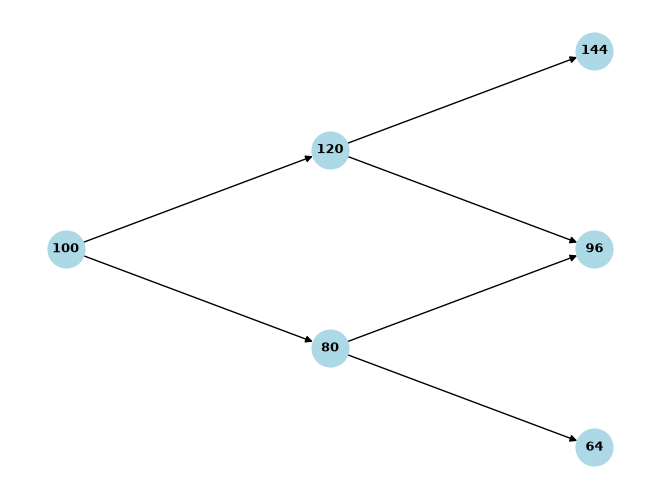

In [197]:
nx.draw(
    G,
    pos,
    with_labels=False,
    node_color="lightblue",
    node_size=700,
    arrows=True
)

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_weight='bold')

In [198]:
def build_tree(S, u, d, steps=3):
    G = nx.DiGraph()
    node_labels = {}
    for i in range(steps):
        for j in range(i+1):
            print('i, j: ', i, j)
            G.add_node((i+1, j+1))
            node_labels[(i+1, j+1)] = round(S * (u**j) * (d**(i-j)), 2)

            if i>0 and (i, j+1) in node_labels:
                G.add_edge((i,j+1), (i+1, j+1))
            if i>0 and (i, j) in node_labels:
                G.add_edge((i, j), (i+1, j+1))
    pos = {node: (node[0], node[1] - node[0] / 2) for node in G.nodes()}

            
    return G, pos, node_labels




i, j:  0 0
i, j:  1 0
i, j:  1 1
i, j:  2 0
i, j:  2 1
i, j:  2 2


{(1, 1): Text(1, 0.5, '100.0'),
 (2, 1): Text(2, 0.0, '80.0'),
 (2, 2): Text(2, 1.0, '150.0'),
 (3, 1): Text(3, -0.5, '64.0'),
 (3, 2): Text(3, 0.5, '120.0'),
 (3, 3): Text(3, 1.5, '225.0')}

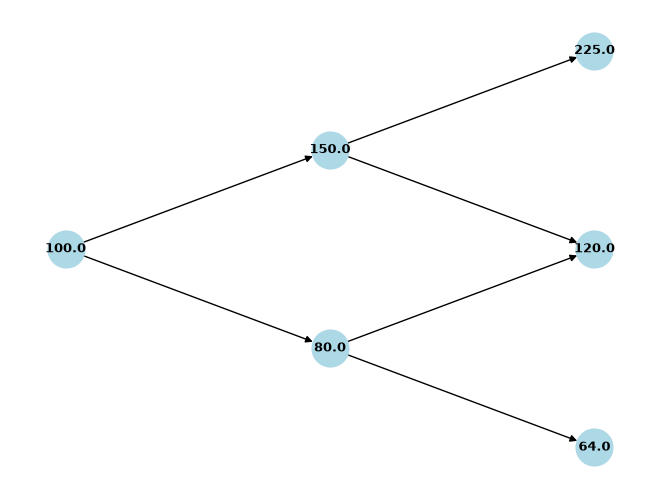

In [199]:
G_b, pos_b, node_labels_b = build_tree(100, 1.5, 0.8, steps=3)

nx.draw(
    G_b,
    pos_b,
    with_labels=False,
    node_color="lightblue",
    node_size=700,
    arrows=True
)

nx.draw_networkx_labels(G_b, pos_b, labels=node_labels_b, font_size=9, font_weight='bold')